## __Data Science: Capstone Part 2: Lightning Talk 2__

### Overview

On the **One** topic you have selected you would need to:
1. Refine your problem statement. for more info [ML-Framing-a-Data-Science-Problem]() **<--- will cover on Tuesday**
2. Create / Compile a data dictionary
3. Clean the data and Perform in-depth EDA (Insights + EDA for Modeling)
4. Outline proposed preprocessing/feature engineering and models

### Presentation Requirements (5 Minutes)
* Refined Problem Statement  (including Success Metrics)
* Potential Audience
* Goals & Objectives
    * Type of Models (e.g: Regression/Classification)
    * Number of models
    * Evaluation Metrics
* About the data (Data Dictionary and EDA for Modeling) - Keep this short 
* Progress report (Challenges & Next Steps)



___Note: EDA for Image based Topics___
* Classes (Target)
* Settings (Transformation)
* Data Limitations


# Adult Income Prediction
Data Source : https://www.kaggle.com/datasets/mosapabdelghany/adult-income-prediction-dataset

# Problem Statement

**The Raw Issue:** Financial and workforce organizations spend heavily on generic, one-size-fits-all outreach because they cannot tell upfront which individuals in their applicant pool are likely to be high earners — wasting premium offers on low-conversion leads and missing genuine high-value prospects.

**The Structured Objective:** We aim to classify individuals as high income (>$50K/year) or low income (≤$50K/year) using demographic and employment features — age, education, occupation, hours worked, and capital gains/losses — collected at intake. This lets marketing and outreach teams target premium offers at the predicted high-income segment (~24% of applicants) instead of blanket outreach, while directing the rest toward affordable products.

**Success metric:** F1-score ≥ 0.70 and ROC-AUC ≥ 0.85 on the >$50K class, improving targeting precision over the current generic approach.

*Classification problem.*

## Objectives
List the key questions guiding your analysis and modeling:
- What features influence the target variable?
- Can feature engineering improve model performance?
- How do different model versions compare?

# Data Inspection

## Data Dictionary
| Column         | Type        | Description                  |
| -------------- | ----------- | ---------------------------- |
| age            | Numerical   | Age of individual            |
| workclass      | Categorical | Type of employment           |
| fnlwgt         | Numerical   | Census population weight     |
| education      | Categorical | Education level              |
| education.num  | Numerical   | Education level encoded      |
| marital.status | Categorical | Marital status               |
| occupation     | Categorical | Job type                     |
| relationship   | Categorical | Household relationship       |
| race           | Categorical | Race category                |
| sex            | Categorical | Gender                       |
| capital.gain   | Numerical   | Capital gains                |
| capital.loss   | Numerical   | Capital losses               |
| hours.per.week | Numerical   | Weekly working hours         |
| native.country | Categorical | Country of origin            |
| income         | Categorical | Income class (>50K or <=50K) |


In [2]:
# organize your imports in this cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## Data Overview
Load and inspect the dataset
- Source and format
- .head(), .info(), .describe(),…

In [3]:
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# Data Cleaning
Handle missing values, outliers, and inconsistencies

In [4]:
df.shape

(32561, 15)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


In [6]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [7]:
df.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

In [8]:
df = df.replace('?', np.nan)
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [9]:
for col in ['workclass', 'occupation', 'native.country']:
    df[col] = df[col].fillna(df[col].mode()[0])


df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

# Exploratory Data Analysis (EDA)
Answer objectives using visual and statistical insights
- Trends, relationships, anomalies
- Outlier and missing values treatment
- Univariate, bivariate, or multivariate analysis
    - Histograms, box plots, bar charts
    - Correlation matrix for continuous columns (required if applicable)


In [10]:
numerical_features = df.select_dtypes(include=['int64']).columns
numerical_features

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='str')

In [11]:
len(numerical_features)

6

In [12]:
categorical_features = df.select_dtypes(include=['object']).columns
categorical_features

C:\Users\a0355\AppData\Local\Temp\ipykernel_34784\266441915.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='str')

In [13]:
len(categorical_features)

9

In [14]:
df['income_binary'] = df['income'].map({
    '<=50K':0,
    '>50K':1
})

df[['income','income_binary']].head()

,income,income_binary
0,<=50K,0
1,<=50K,0
2,<=50K,0
3,<=50K,0
4,<=50K,0


In [15]:
corr = df.corr(numeric_only=True)
corr

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income_binary
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756,0.234037
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768,-0.009463
education.num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123,0.335154
capital.gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409,0.223329
capital.loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256,0.150526
hours.per.week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000,0.229689
income_binary,0.234037,-0.009463,0.335154,0.223329,0.150526,0.229689,1.000000


In [16]:
corr['income_binary'].sort_values(ascending=False)

income_binary     1.000000
education.num     0.335154
age               0.234037
hours.per.week    0.229689
capital.gain      0.223329
capital.loss      0.150526
fnlwgt           -0.009463
Name: income_binary, dtype: float64

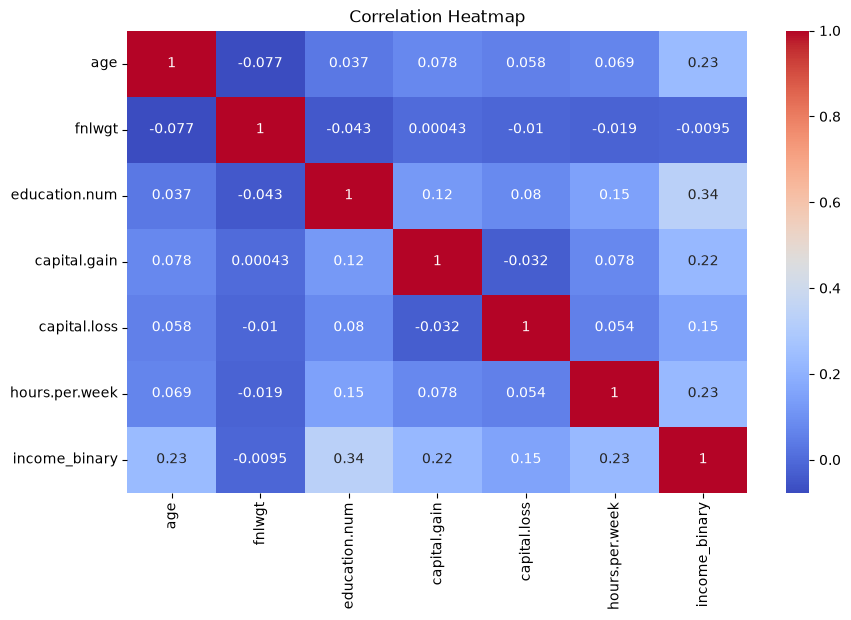

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

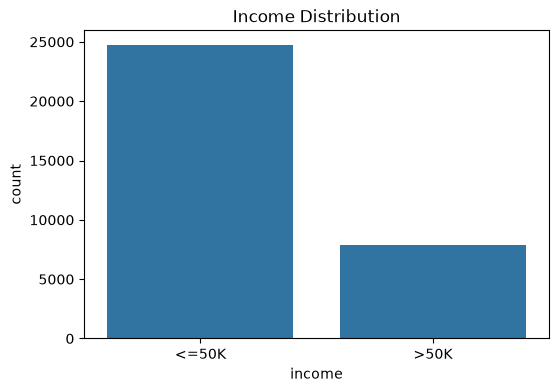

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='income'
)

plt.title("Income Distribution")

plt.show()

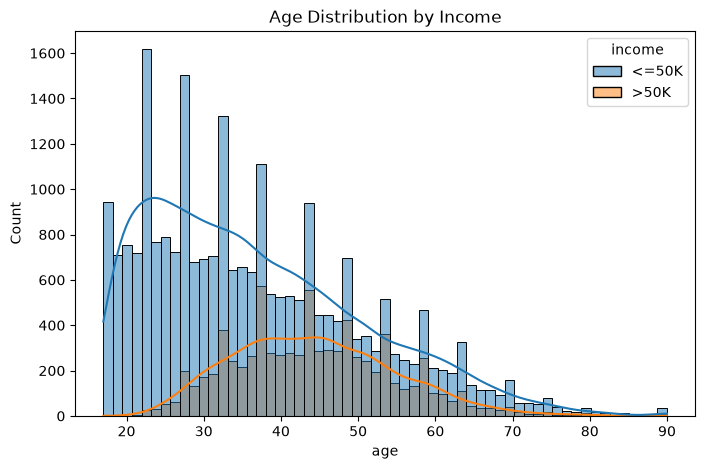

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='age',
    hue='income',
    kde=True
)

plt.title("Age Distribution by Income")

plt.show()

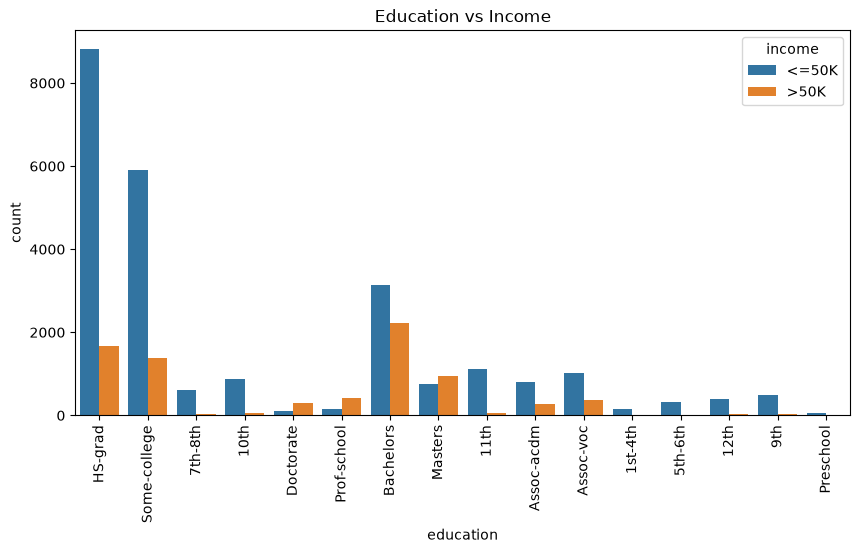

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='education',
    hue='income'
)

plt.xticks(rotation=90)

plt.title("Education vs Income")

plt.show()

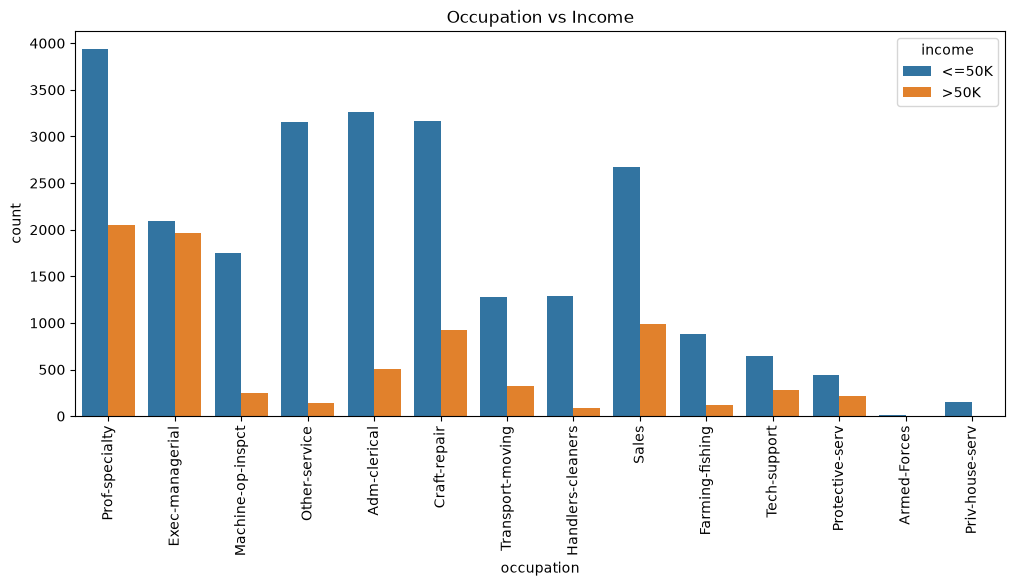

In [21]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='occupation',
    hue='income'
)

plt.xticks(rotation=90)

plt.title("Occupation vs Income")

plt.show()

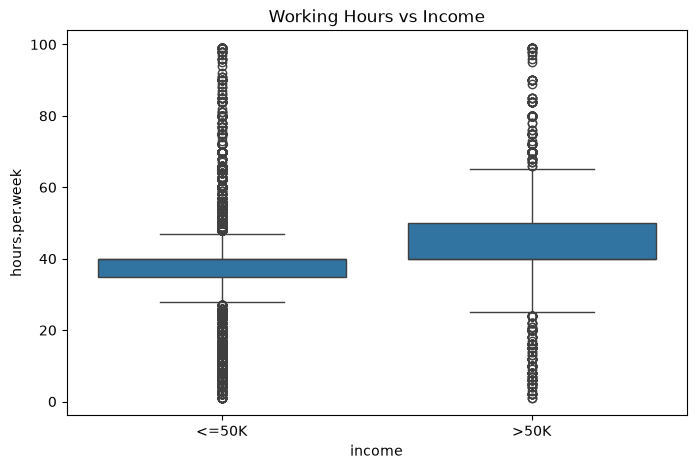

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='income',
    y='hours.per.week'
)

plt.title("Working Hours vs Income")

plt.show()

In [23]:
df[['age',
    'fnlwgt',
    'capital.gain',
    'capital.loss',
    'hours.per.week']].describe()

,age,fnlwgt,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,99999.000000,4356.000000,99.000000


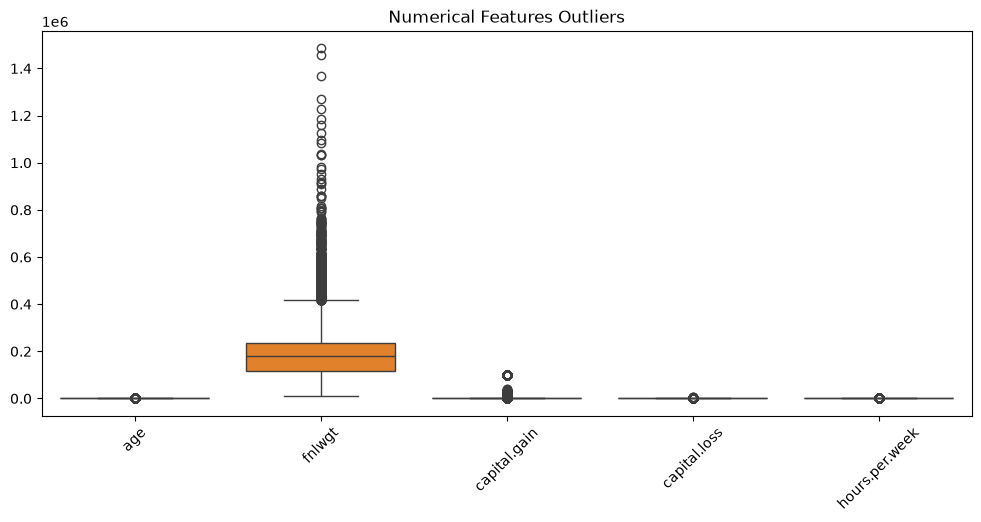

In [24]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=df[
        ['age',
         'fnlwgt',
         'capital.gain',
         'capital.loss',
         'hours.per.week']
    ]
)

plt.xticks(rotation=45)

plt.title("Numerical Features Outliers")

plt.show()

EDA Findings

- The target variable is a binary classification problem:
  <=50K and >50K.

- The dataset contains:
  - 6 numerical features
  - 9 categorical features

- Missing values were found in:
  - workclass
  - occupation
  - native.country

  These were handled using mode imputation because they are categorical features.

- Education level showed the strongest relationship with income.

- Outliers were detected mainly in:
  - fnlwgt
  - capital.gain
  - capital.loss

  These values were kept because they represent real variations in income-related data.

# Data Preprocessing & Feature Engineering
Transforming, encoding, standardization and preparing features
- **You only need to outline your approach here. No need to execute**

In [25]:
X = df.drop(
    ['income','income_binary'],
    axis=1
)

y = df['income_binary']

In [26]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(26048, 15)
(6513, 15)
income_binary
0    0.759175
1    0.240825
Name: proportion, dtype: float64
income_binary
0    0.759251
1    0.240749
Name: proportion, dtype: float64


In [28]:
numerical_features = X_train.select_dtypes(
    include=['int64']
).columns


categorical_features = X_train.select_dtypes(
    include=['object']
).columns

C:\Users\a0355\AppData\Local\Temp\ipykernel_34784\2106995281.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [29]:
print("Numerical Features:")
print(numerical_features)


print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='str')

Categorical Features:
Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='str')


In [30]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

In [32]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)

(26048, 106)


# Modelling Approach
What are the models you are planning to build for your capstone.
- **You only need to outline your approach here. No need to execute**

Modelling Approach

This project will be treated as a binary classification problem.

The following models will be developed and compared:

1. Logistic Regression:
Used as a baseline model to establish initial performance.

2. Decision Tree:
Used to capture non-linear relationships between features and income prediction.

3. Random Forest:
Used to improve performance by combining multiple decision trees and reducing overfitting.

4. Gradient Boosting:
Used as an advanced ensemble method to improve predictive performance.

Models will be evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

The best performing model will be selected based on evaluation metrics.